# Load and test saved model

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from jax.nn import relu
import jax.numpy as jnp
from jax.typing import ArrayLike
import jax
from WMSE import WMSE, WMSE_metric


jax.config.update("jax_enable_x64", False)

#### graphical
import matplotlib.pyplot as plt
import corner

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers
from matplotlib.gridspec import GridSpec
##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="1"

physical_devices = tf.config.list_physical_devices("GPU") 

tf.config.experimental.set_memory_growth(physical_devices[0], True)

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

modelpath = '/home/hatte/M4/models'

2025-04-08 11:41:56.333694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744108916.345382 3170692 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744108916.349066 3170692 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Current GPU usage:
 - GPU0: 0B



I0000 00:00:1744108918.202788 3170692 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14963 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:61:00.0, compute capability: 8.6


In [2]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])

df_full['lognumax'] = np.log10(df_full['numax']*3090)

df_full['logdnuSer'] = np.log10(df_full['dnuSer']*135)

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnuSer']  # 10 modes for now

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())

## check df_norm.describe looks reasonable (min=0, max=1):
df_norm.describe()



,massini,zini,yini,alphaMLT,age,eta,alphaFe,FeH,logLPhot,Teff,lognumax,logdnuSer
count,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06
mean,5.320517e-01,1.169785e-01,4.801320e-01,5.207879e-01,2.894701e-01,4.995957e-01,5.104678e-01,5.510095e-01,6.590481e-01,1.893095e-01,3.204782e-01,3.007441e-01
std,2.741396e-01,1.503168e-01,2.866208e-01,2.874298e-01,2.407603e-01,2.886541e-01,3.224309e-01,2.766927e-01,1.768257e-01,6.669141e-02,2.203469e-01,2.388832e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.050000e-01,1.490123e-02,2.313656e-01,2.751358e-01,1.004077e-01,2.494505e-01,2.500000e-01,3.284310e-01,5.532432e-01,1.458403e-01,1.430966e-01,1.080578e-01
50%,5.362500e-01,5.506925e-02,4.703010e-01,5.304316e-01,2.083946e-01,4.997558e-01,5.000000e-01,5.743831e-01,6.935266e-01,1.897028e-01,2.651610e-01,2.382943e-01
75%,7.675000e-01,1.620700e-01,7.242537e-01,7.715646e-01,4.200869e-01,7.497558e-01,7.500000e-01,7.868256e-01,7.945543e-01,2.266111e-01,4.502288e-01,4.408151e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [3]:
unnormed_weights_dict = {'FeH':0.01, 'logLPhot':0.001, 'Teff':10, 'lognumax':0.0001, 'logdnuSer':0.0001}

unnormed_weights = list(unnormed_weights_dict.values())

weights = [2*unnormed_weights_dict[i]/(df[i].max() - df[i].min()) for i in outputs]

In [4]:
weights

[np.float64(0.00902176473219089),
 np.float64(0.0009398816379978598),
 np.float64(0.0032524327234457837),
 np.float64(0.00010740247435805763),
 np.float64(0.00015030428317496362)]

In [3]:
#### train/test split with seed 
seed = 42

df_train = df_norm.sample(frac=0.95, random_state=seed)
df_test = df_norm.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.05, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Validation set: ", len(df_val_inputs))
print("Test set: ", len(df_test))

Training set:  6754081
Validation set:  355478
Test set:  374187


In [4]:
######## define architecture:
n_dense_layers = 6

dense_layer_units = 128

Nepochs = 5000

learning_rate = 0.001

model_name = 'smart-logLPhot-lognumax-logdnuSer-exponent-6e-6'

loss_func = 'WMSE'
###### Checkpointing

custom_objects =  {'WMSE':WMSE_metric}

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

model= tf.keras.models.load_model(checkpoint_dir, custom_objects = custom_objects)


In [5]:
model.summary()

Model: "smart-logLPhot-lognumax-logdnuSer-exponent-6e-6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,689 (987.07 KB)

 Trainable params: 84,229 (329.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 168,460 (658.05 KB)

In [6]:
def unnorm(df_norm, df_min, df_max):
    df_unnorm = (df_norm*(df_max-df_min)) + df_min
    return df_unnorm

preds_norm = model(np.array(df_test[inputs]))

df_preds_norm = pd.DataFrame(preds_norm, columns=outputs)
df_preds_unnorm = unnorm(df_preds_norm, df[outputs].min(), df[outputs].max())

df_test_unnorm = unnorm(df_test, df.min(), df.max())

In [7]:
def plot_residuals(test, preds, outputs, units, factor, filename, save = False):
    
    fig = plt.figure(figsize = (20, 3))
    
    gs = GridSpec(1, len(outputs), wspace = 0.2)
    
    axs = [fig.add_subplot(gs[i]) for i in range(len(outputs))]

    for i in range(len(outputs)):
        if 'log' in outputs[i]:

            name = outputs[i].split('log')[1]
        ##Summary stats##
            mean = np.mean((10**df_test_unnorm[outputs[i]].values*factor[i] - 10**df_preds_unnorm[outputs[i]].values*factor[i]))
        
            std = np.std((10**df_test_unnorm[outputs[i]].values*factor[i] - 10**df_preds_unnorm[outputs[i]].values*factor[i]))
        
            ranges = [mean - 4*std, mean+4*std]


        ##Plotting##

            
            axs[i].hist((10**df_test_unnorm[outputs[i]].values*factor[i] - 10**df_preds_unnorm[outputs[i]].values*factor[i]),\
                    bins = 100, density = True, range = ranges, histtype = 'step', fill = True, facecolor = 'lightblue',\
                   edgecolor = 'slategrey', linewidth = 2)
        
            axs[i].set_xlabel(f'{name}'r'$_{\mathrm{test}}$'r'$-$'f'{name}'r'$_{\mathrm{pred}}$ 'f'[{units[i]}]')

        else:
            mean = np.mean((df_test_unnorm[outputs[i]].values*factor[i] - df_preds_unnorm[outputs[i]].values*factor[i]))
        
            std = np.std((df_test_unnorm[outputs[i]].values*factor[i] - df_preds_unnorm[outputs[i]].values*factor[i]))
        
            ranges = [mean - 4*std, mean+4*std]

            axs[i].hist((df_test_unnorm[outputs[i]].values*factor[i] - df_preds_unnorm[outputs[i]].values*factor[i]),\
                    bins = 100, density = True, range = ranges, histtype = 'step', fill = True, facecolor = 'lightblue',\
                   edgecolor = 'slategrey', linewidth = 2)

            axs[i].set_xlabel(f'{outputs[i]}'r'$_{\mathrm{test}}$'r'$-$'f'{outputs[i]}'r'$_{\mathrm{pred}}$ 'f'[{units[i]}]')
        
        axs[i].axvline(mean + std, color = 'black', linestyle = '--', label = f'std = {round(std, 2)}')
        
        axs[i].axvline(mean - std, color = 'black', linestyle = '--', )

        axs[i].axvspan(mean- std, mean + std, color = 'deeppink', alpha = 0.2)
        
        axs[i].axvline(mean, color = 'deeppink',  label = f'mean = {round(mean, 2)}', linewidth = 2)
        
        axs[i].set_title(r'$\mu$ ='f'{round(mean, 2)}, 'r'$\sigma$ ='f'{round(std, 2)}')

        axs[i].set_yticks([])
    
    if save == True:
        fig.savefig(f'../figs/{filename}-residuals.png', bbox_inches = 'tight', dpi = 150)


    return fig

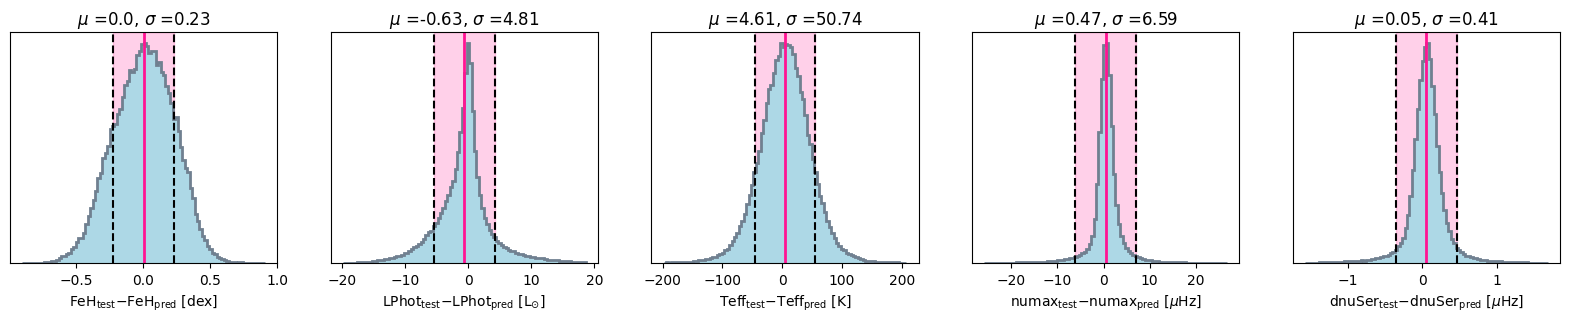

In [8]:
units = ['dex', r'L$_{\odot}$', 'K', r'$\mu$Hz', r'$\mu$Hz']
solarnumax = 3090
solardnu = 135
factor = [1, 1, 1, 1, 1]

fig = plot_residuals(df_test_unnorm, df_preds_unnorm, outputs, units, factor, filename = f'{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}', save = False)

'smart-logLPhot-lognumax-logdnuSer-nlayers-2-nunits-512-epochs-5000-lrate-0.001'

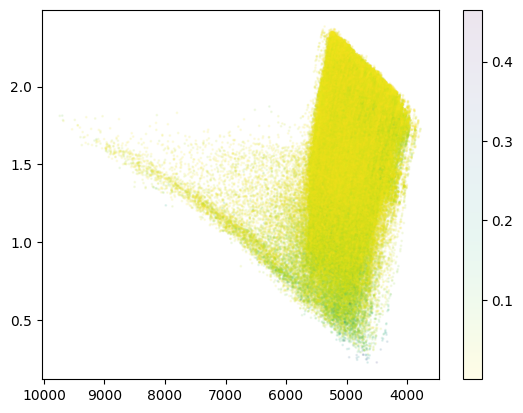

In [40]:

plt.scatter(df_preds_unnorm['Teff'], df_preds_unnorm['logLPhot'], alpha = 0.1, s = 1,c = np.abs((df_preds_unnorm['logLPhot'].values - df_test_unnorm['logLPhot'].values)/df_test_unnorm['logLPhot'].values), cmap= 'viridis_r')
#plt.semilogy()
plt.colorbar()
plt.gca().invert_xaxis()

In [12]:
w_ = []
b_ = []

for i in range(1, 4):
    w_.append(model.layers[i].get_weights()[0])
    b_.append(model.layers[i].get_weights()[1])

from jax.typing import ArrayLike

weights = [jnp.array(w) for w in w_]
bias = [jnp.array(b) for b in b_]


def model_jax(weights, biases, x: ArrayLike) -> jnp.ndarray:
        x = jnp.array(x)
        for w, b in zip(weights[:-1], bias[:-1]):
            x = relu(jnp.matmul(x, w) + b)
        x = jnp.matmul(x, weights[-1]) + bias[-1]
        return x

In [13]:
model_jax(weights, bias, jnp.stack(list(df_test.loc[21, inputs[i]] for i in range(len(inputs))), axis = -1))

Array([0.50400466, 0.3297841 , 0.32420197, 0.49505776, 0.6386552 ],      dtype=float32)

In [19]:
np.array(df_test[inputs])

array([[0.5       , 0.03602288, 0.49996948, ..., 0.15498245, 0.5       ,
        0.5       ],
       [0.5       , 0.03602288, 0.49996948, ..., 0.15743716, 0.5       ,
        0.5       ],
       [0.5       , 0.03602288, 0.49996948, ..., 0.15836671, 0.5       ,
        0.5       ],
       ...,
       [0.0975    , 0.02565661, 0.19418839, ..., 0.83160337, 0.7546398 ,
        0.625     ],
       [0.0975    , 0.02565661, 0.19418839, ..., 0.83161109, 0.7546398 ,
        0.625     ],
       [0.0975    , 0.02565661, 0.19418839, ..., 0.83182932, 0.7546398 ,
        0.625     ]])

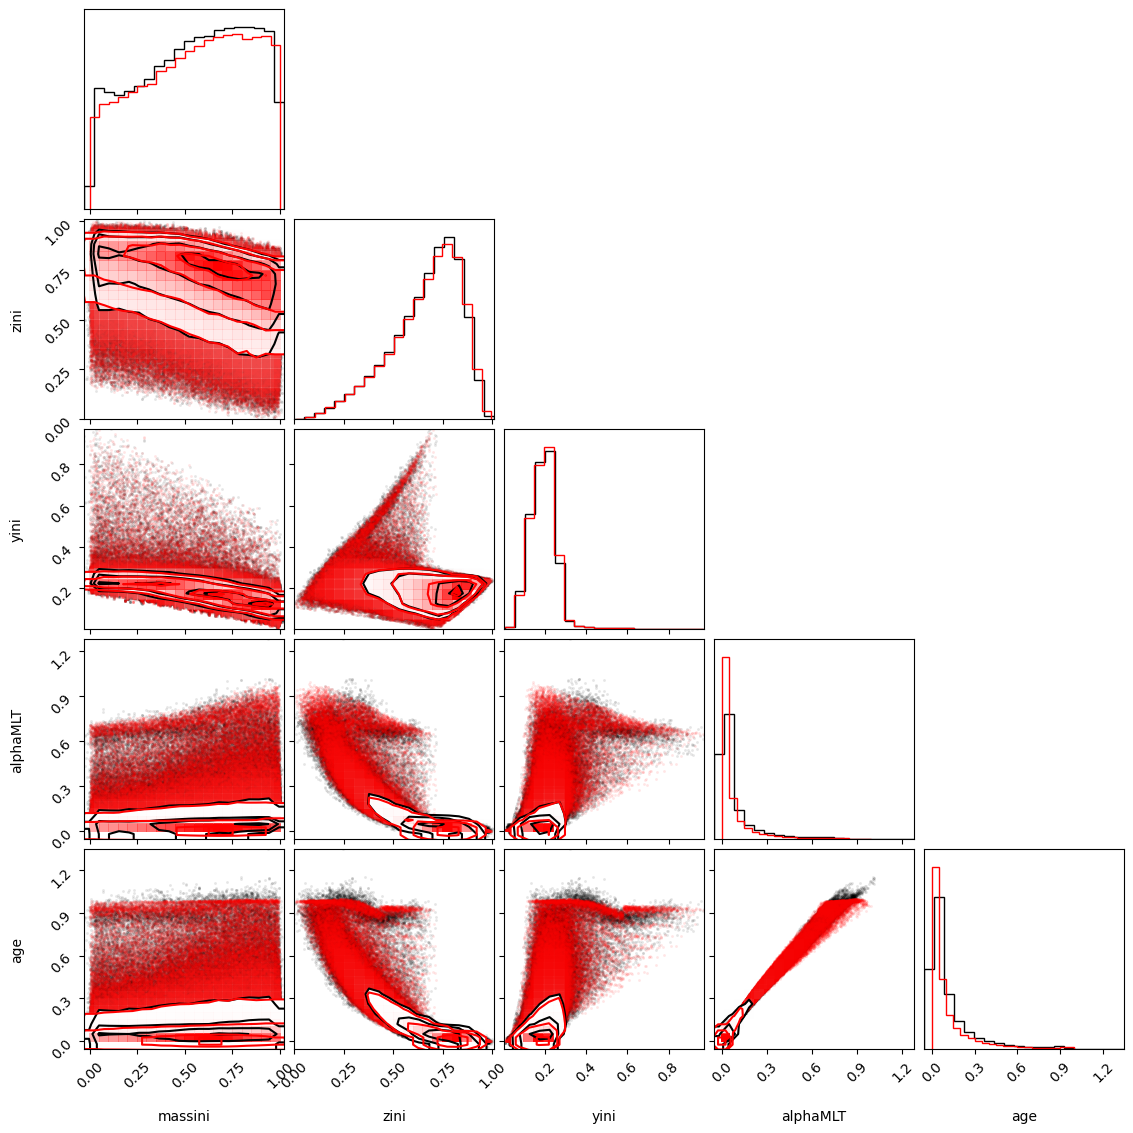

In [14]:
fig = corner.corner(model(np.array(df_test[inputs])).numpy(), labels = inputs)
corner.corner(np.array(df_test[outputs]), fig = fig, color = 'red')
plt.show()

In [6]:
preds_norm = model(np.array(df_test[inputs]))

df_preds_norm = pd.DataFrame(preds_norm, columns=outputs)
df_preds_unnorm = unnorm(df_preds_norm, df[outputs].min(), df[outputs].max())

df_test_unnorm = unnorm(df_test, df.min(), df.max())


fig = corner.corner(model(np.array(df_test[inputs])).numpy(), labels = outputs)
corner.corner(np.array(df_test[outputs]), fig = fig, color = 'red')
plt.show()

2025-02-20 10:20:01.718558: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 730.83MiB (rounded to 766334976)requested by op BiasAdd
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-02-20 10:20:01.718735: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:508] ***************************************************************_____________________________________
2025-02-20 10:20:01.718765: W tensorflow/core/framework/op_kernel.cc:1841] OP_REQUIRES failed at bias_op.cc:270 : RESOURCE_EXHAUSTED: OOM when allocating tensor with shape[374187,512] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc


ResourceExhaustedError: Exception encountered when calling Dense.call().

[1m{{function_node __wrapped__BiasAdd_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[374187,512] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:BiasAdd][0m

Arguments received by Dense.call():
  • inputs=tf.Tensor(shape=(374187, 7), dtype=float32)
  • training=None

In [7]:
inputs

['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe']

In [11]:

def unnorm(value, parameter_name, normalisation_constants):
   
   min_ = normalisation_constants[parameter_name][0]
   
   max_ = normalisation_constants[parameter_name][1]

   return value*(max_ - min_) + min_

def norm(value, parameter_name, normalisation_constants):
   
   min_ = normalisation_constants[parameter_name][0]
   
   max_ = normalisation_constants[parameter_name][1]

   return (value - min_)/(max_ - min_)

normconsts = np.load('../data/Chiara-normconsts.npy', allow_pickle = True).item()

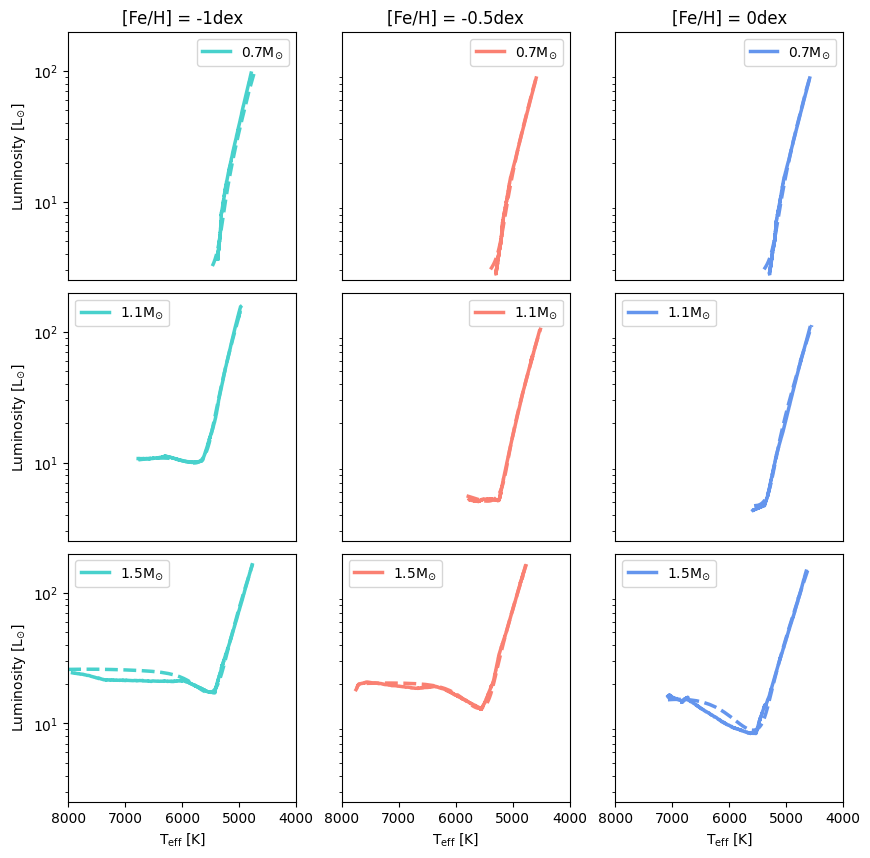

In [12]:
colors = ['mediumturquoise', 'salmon', 'cornflowerblue']

fig = plt.figure(figsize = (10,10))

gs = GridSpec(3, 3, wspace = 0.2, hspace = 0.05)
axs_row1 = [fig.add_subplot(gs[0, i]) for i in range(3)]
axs_row2 = [fig.add_subplot(gs[1, i]) for i in range(3)]
axs_row3 = [fig.add_subplot(gs[2, i]) for i in range(3)]

axs = np.vstack([axs_row1, axs_row2, axs_row3])

masses = [norm(i, 'massini', normconsts) for i in [0.7, 1.1, 1.5]]
metals = [norm(i, 'FeH', normconsts) for i in [-1, -0.5, 0]]
for k in range(len(masses)):
    df_ = df_norm[df_norm['massini'] == masses[k]]
    for j in range(len(metals)):
        diff_met = np.abs(df_['FeH'] - metals[j])
        star = df_norm.loc[[diff_met.sort_values().index[0]]]
        track_star = df_norm.merge(star[['massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']])
        testerdf = pd.DataFrame(columns = inputs)
        testerdf['age'] = np.linspace(np.min(track_star['age']), np.max(track_star['age']), 1000)

        for i in ['massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']:
            testerdf[i] = star[i].values[0]


        testerout = model(np.array(testerdf)).numpy()

        axs[k, j].semilogy(unnorm(track_star['Teff'], 'Teff', normconsts), 10**unnorm(track_star['logLPhot'], 'logLPhot', normconsts), color = colors[j], linestyle= '--', linewidth = 2.5)
        axs[k, j].semilogy(unnorm(testerout.T[2], 'Teff', normconsts), 10**unnorm(testerout.T[1], 'logLPhot', normconsts), color = colors[j], label = f'{[0.7, 1.1, 1.5][k]}'r'M$_{\odot}$', linewidth = 2.5)
        axs[k, j].set_ylim(10**0.4, 10**2.3)
        axs[k, j].set_xlim(4000, 8000)
        axs[k, j].invert_xaxis()
        axs[k, j].legend()
        if k < 2:
            axs[k, j].set_xticks([])

        else:
            axs[k, j].set_xlabel(r'T$_{\mathrm{eff}}$ [K]')

        if j > 0:
            axs[k, j].set_yticks([])

        else:
            axs[k, j].set_ylabel(r'Luminosity [L$_{\odot}$]')

axs[0, 0].set_title(r'[Fe/H] = -1dex')
axs[0, 1].set_title(r'[Fe/H] = -0.5dex') 
axs[0, 2].set_title(r'[Fe/H] = 0dex') 

fig.savefig(f'../figs/trackwise-predictions-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}.png', bbox_inches = 'tight', dpi = 150)


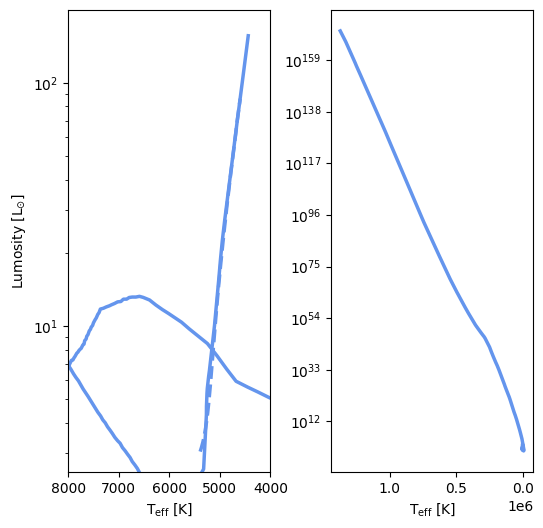

In [106]:
fig = plt.figure(figsize = (6,6))

gs = GridSpec(1, 2, wspace = 0.3, hspace = 0.05)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
df_ = df_norm[df_norm['massini'] == masses[0]]
diff_met = np.abs(df_['FeH'] - metals[2])
star = df_norm.loc[[diff_met.sort_values().index[0]]]
track_star = df_norm.merge(star[['massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']])
testerdf = pd.DataFrame(columns = inputs)
testerdf['age'] = np.linspace(np.min(df_norm['age']), np.max(df_norm['age']), 1000)
for i in ['massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']:
            testerdf[i] = star[i].values[0]


testerout = model(np.array(testerdf)).numpy()
ax0.semilogy(unnorm(track_star['Teff'], 'Teff', normconsts), 10**unnorm(track_star['logLPhot'], 'logLPhot', normconsts), color = colors[j], linestyle= '--', linewidth = 2.5)
ax0.semilogy(unnorm(testerout.T[2], 'Teff', normconsts), 10**unnorm(testerout.T[1], 'logLPhot', normconsts), color = colors[j], label = f'{[0.7, 1.1, 1.5][k]}'r'M$_{\odot}$', linewidth = 2.5)
ax0.set_ylim(10**0.4, 10**2.3)
ax0.set_xlim(4000, 8000)
ax0.invert_xaxis()
ax0.set_xlabel(r'T$_{\mathrm{eff}}$ [K]')
ax0.set_ylabel(r'Lumosity [L$_{\odot}$]')

ax1.semilogy(unnorm(track_star['Teff'], 'Teff', normconsts), 10**unnorm(track_star['logLPhot'], 'logLPhot', normconsts), color = colors[j], linestyle= '--', linewidth = 2.5)
ax1.semilogy(unnorm(testerout.T[2], 'Teff', normconsts), 10**unnorm(testerout.T[1], 'logLPhot', normconsts), color = colors[j], label = f'{[0.7, 1.1, 1.5][k]}'r'M$_{\odot}$', linewidth = 2.5)
ax1.invert_xaxis()
ax1.set_xlabel(r'T$_{\mathrm{eff}}$ [K]')_

fig.savefig('../figs/predicting_outside_range.png', bbox_inches = 'tight', dpi = 150)

In [41]:
testerout

array([[ -4651.649 ,  67532.71  , -10132.917 ,  31556.426 ,  27656.758 ],
       [ -4651.22  ,  67536.516 , -10134.721 ,  31555.81  ,  27650.193 ],
       [ -4654.6953,  67558.305 , -10134.559 ,  31573.893 ,  27671.887 ],
       ...,
       [ -5602.294 ,  81341.54  , -12210.055 ,  38002.36  ,  33301.105 ],
       [ -5602.89  ,  81348.91  , -12212.6   ,  38001.94  ,  33298.383 ],
       [ -5603.098 ,  81361.1   , -12196.846 ,  38002.82  ,  33303.777 ]],
      dtype=float32)

In [44]:
testerout

array([[0.786757  , 0.1345995 , 0.24558994, 0.79640007, 0.9813036 ],
       [0.7867404 , 0.13437939, 0.24538705, 0.79493237, 0.9798082 ],
       [0.7867471 , 0.13475844, 0.24543548, 0.7941545 , 0.97894466],
       ...,
       [0.79441047, 0.7539619 , 0.10504326, 0.00716065, 0.0095716 ],
       [0.794386  , 0.7554227 , 0.10492373, 0.00715365, 0.00931233],
       [0.7943777 , 0.75694907, 0.10457534, 0.00691462, 0.00877687]],
      dtype=float32)

In [45]:
testerdf

,massini,zini,yini,alphaMLT,age,eta,alphaFe
0,0.2725,0.152707,0.846102,0.361211,0.386343,0.305495,0.5
1,0.2725,0.152707,0.846102,0.361211,0.386368,0.305495,0.5
2,0.2725,0.152707,0.846102,0.361211,0.386394,0.305495,0.5
3,0.2725,0.152707,0.846102,0.361211,0.386419,0.305495,0.5
4,0.2725,0.152707,0.846102,0.361211,0.386444,0.305495,0.5
...,...,...,...,...,...,...,...
995,0.2725,0.152707,0.846102,0.361211,0.411426,0.305495,0.5
996,0.2725,0.152707,0.846102,0.361211,0.411452,0.305495,0.5
997,0.2725,0.152707,0.846102,0.361211,0.411477,0.305495,0.5
998,0.2725,0.152707,0.846102,0.361211,0.411502,0.305495,0.5
